# Image Processing Workshop

This notebook demonstrates various image processing techniques including loading datasets, image manipulation, normalization, and statistical analysis.

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random

In [3]:
import kagglehub

# Download the latest : https://www.kaggle.com/datasets/msarmi9/food101tiny
path = kagglehub.dataset_download("msarmi9/food101tiny")

print("Path to dataset files:", path)

Path to dataset files: /Users/aymnouha/.cache/kagglehub/datasets/msarmi9/food101tiny/versions/1


## Dataset Import and Loading

We'll be working with the Food101-tiny dataset which contains various food categories. Let's start by downloading and exploring the dataset.

In [4]:
# Set up the path to our chosen food category
food_category = 'apple_pie'
dataset_path = os.path.join(path, 'data', 'food-101-tiny', 'train', food_category)

In [5]:
# List all image files in the selected category
img_files = os.listdir(dataset_path)
print(f'Total number of images found: {len(img_files)}')
print("Sample image filenames:", img_files[:5])

Total number of images found: 150
Sample image filenames: ['1420227.jpg', '1088809.jpg', '1214326.jpg', '1246460.jpg', '1284682.jpg']


In [6]:
from PIL import Image

# Load a random image and display its properties
selected_img_path = os.path.join(dataset_path, random.choice(img_files))
loaded_image = Image.open(selected_img_path)

print("Selected image path:", selected_img_path)
print("Image dimensions (Width x Height):", loaded_image.size)
print("Image mode:", loaded_image.mode)

Selected image path: /Users/aymnouha/.cache/kagglehub/datasets/msarmi9/food101tiny/versions/1/data/food-101-tiny/train/apple_pie/1633812.jpg
Image dimensions (Width x Height): (512, 512)
Image mode: RGB


## Loading and Inspecting Image Properties

Let's load a sample image and examine its basic properties like dimensions and color mode.

## Image Visualization Gallery

Let's create a visual gallery showing multiple sample images from our dataset.

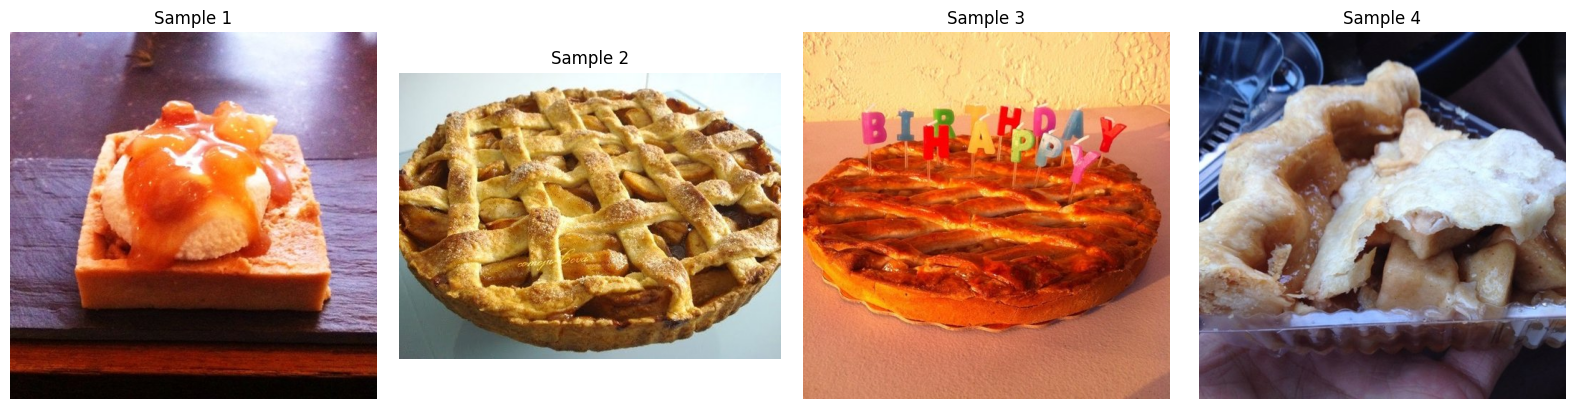

In [7]:
# Create a gallery of sample images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, ax in enumerate(axes):
    sample_path = os.path.join(dataset_path, random.choice(img_files))
    sample_img = Image.open(sample_path)
    ax.imshow(sample_img)
    ax.set_title(f'Sample {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

## Pixel Value Normalization

Converting pixel values from the standard 0-255 range to normalized 0-1 range for better processing.

In [8]:
# Convert image to numpy array for processing
img_array = np.array(loaded_image)
print("Original data type:", img_array.dtype)
print("Original pixel value range:", img_array.min(), "to", img_array.max())

# Normalize pixels to 0-1 range
normalized_img = img_array.astype(np.float32) / 255.0
print("Normalized data type:", normalized_img.dtype)
print("Normalized pixel range:", normalized_img.min(), "to", normalized_img.max())

Original data type: uint8
Original pixel value range: 0 to 255
Normalized data type: float32
Normalized pixel range: 0.0 to 1.0


## Statistical Analysis of Image Data

Computing basic statistical measures of our normalized image data.

In [9]:
# Calculate statistical measures
pixel_mean = normalized_img.mean()
pixel_std = normalized_img.std()
pixel_variance = normalized_img.var()

print(f"Mean pixel intensity: {pixel_mean:.4f}")
print(f"Standard deviation: {pixel_std:.4f}")
print(f"Variance: {pixel_variance:.4f}")

# Per-channel statistics for RGB images
if len(normalized_img.shape) == 3:
    print(f"\nPer-channel means:")
    print(f"Red channel: {normalized_img[:,:,0].mean():.4f}")
    print(f"Green channel: {normalized_img[:,:,1].mean():.4f}")
    print(f"Blue channel: {normalized_img[:,:,2].mean():.4f}")

Mean pixel intensity: 0.5469
Standard deviation: 0.2461
Variance: 0.0606

Per-channel means:
Red channel: 0.7580
Green channel: 0.5467
Blue channel: 0.3362
